# Inherently Interpretable Models
### Breast Cancer Wisconsin (Diagnostic) dataset

**Objective:** implement and evaluate inherently interpretable machine learning
models for breast cancer classification, and understand how their internal
parameters, decision rules, nearest examples, likelihood contributions and
feature-wise shape functions can be used to explain predictions. Compare the
accuracy and interpretability of the different models.

Six clinically meaningful features are used throughout: `mean_radius`,
`mean_texture`, `mean_perimeter`, `mean_smoothness`, `mean_concavity`,
`worst_area`.


## Step 1-2: Imports

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from pygam import LogisticGAM, s

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
     "yellow": "#eda100", "violet": "#4a3aa7", "red": "#e34948",
     "grid": "#d8d7d2", "ink": "#0b0b0b", "muted": "#6d6c68"}

plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["grid"], "axes.labelcolor": C["muted"],
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "grid.color": C["grid"], "grid.linewidth": 0.8,
    "font.size": 10, "legend.frameon": False,
})
print("Ready.")


Ready.


## Step 3-7: Load data, select features, split, standardize

In [2]:
# Step 3 - load the Breast Cancer Wisconsin (Diagnostic) dataset
raw = load_breast_cancer(as_frame=True)
df = raw.frame.copy()
df.columns = [c.replace(" ", "_") for c in df.columns]

# sklearn ships 0=malignant, 1=benign; re-encode so 1=malignant (clinically
# intuitive: a HIGHER predicted probability means a MORE malignant reading).
df["target"] = 1 - df["target"]

# Step 4 - six clinically meaningful features
selected_features = ["mean_radius", "mean_texture", "mean_perimeter",
                      "mean_smoothness", "mean_concavity", "worst_area"]

# Step 5 - separate X and y
X = df[selected_features]
y = df["target"]
print("X shape:", X.shape, " class balance:", y.value_counts(normalize=True).round(3).to_dict())

# Step 6 - stratified train/test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("train:", x_train.shape, " test:", x_test.shape)

# Step 7 - standardize (needed for Logistic Regression, k-NN; tree/NB/GAM use raw units)
scaler = StandardScaler()
x_train_s = pd.DataFrame(scaler.fit_transform(x_train), columns=selected_features, index=x_train.index)
x_test_s = pd.DataFrame(scaler.transform(x_test), columns=selected_features, index=x_test.index)

results = {}   # model name -> test accuracy, filled in as we go


X shape: (569, 6)  class balance: {0: 0.627, 1: 0.373}
train: (455, 6)  test: (114, 6)


## Step 8-9: Logistic Regression
Interprets predictions using feature coefficients and odds ratios: each
coefficient is the change in log-odds of malignancy for a one-standard-deviation
increase in that (standardised) feature; `exp(coefficient)` is the odds ratio.

Logistic Regression test accuracy: 0.930

intercept = -0.2340


,coefficient,odds_ratio
worst_area,3.4694,32.1176
mean_texture,1.3998,4.0542
mean_smoothness,1.3645,3.9138
mean_concavity,1.1228,3.0734
mean_radius,0.8172,2.2643
mean_perimeter,0.7056,2.0251


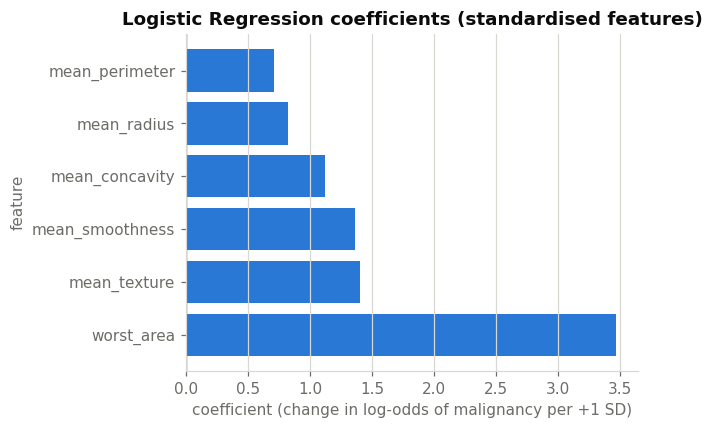


Example interpretation: a one-standard-deviation increase in worst_area is associated with the odds of malignancy multiplying by 32.12x, holding the other five features fixed.


In [3]:
logreg = LogisticRegression(random_state=RANDOM_STATE)
logreg.fit(x_train_s, y_train)

pred = logreg.predict(x_test_s)
results["Logistic Regression"] = accuracy_score(y_test, pred)
print(f"Logistic Regression test accuracy: {results['Logistic Regression']:.3f}")

logreg_table = pd.DataFrame({
    "coefficient": logreg.coef_[0],
    "odds_ratio": np.exp(logreg.coef_[0]),
}, index=selected_features).round(4).sort_values("odds_ratio", ascending=False)
print(f"\nintercept = {logreg.intercept_[0]:.4f}")
display(logreg_table)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(logreg_table.index, logreg_table["coefficient"], color=C["blue"])
ax.set_title("Logistic Regression coefficients (standardised features)")
ax.set_xlabel("coefficient (change in log-odds of malignancy per +1 SD)")
ax.set_ylabel("feature")
ax.axvline(0, color=C["ink"], linewidth=0.8)
ax.xaxis.grid(True)
plt.tight_layout()
plt.show()

print("\nExample interpretation: a one-standard-deviation increase in worst_area is "
      f"associated with the odds of malignancy multiplying by {logreg_table.loc['worst_area', 'odds_ratio']:.2f}x, "
      "holding the other five features fixed.")


## Step 10-11: Decision Tree + explicit IF-THEN rule list
The tree is depth-restricted so a human can read every decision path.
`export_text` renders those root-to-leaf paths directly as IF-THEN rules.

Decision Tree test accuracy: 0.921
Tree depth: 3, number of leaves: 6


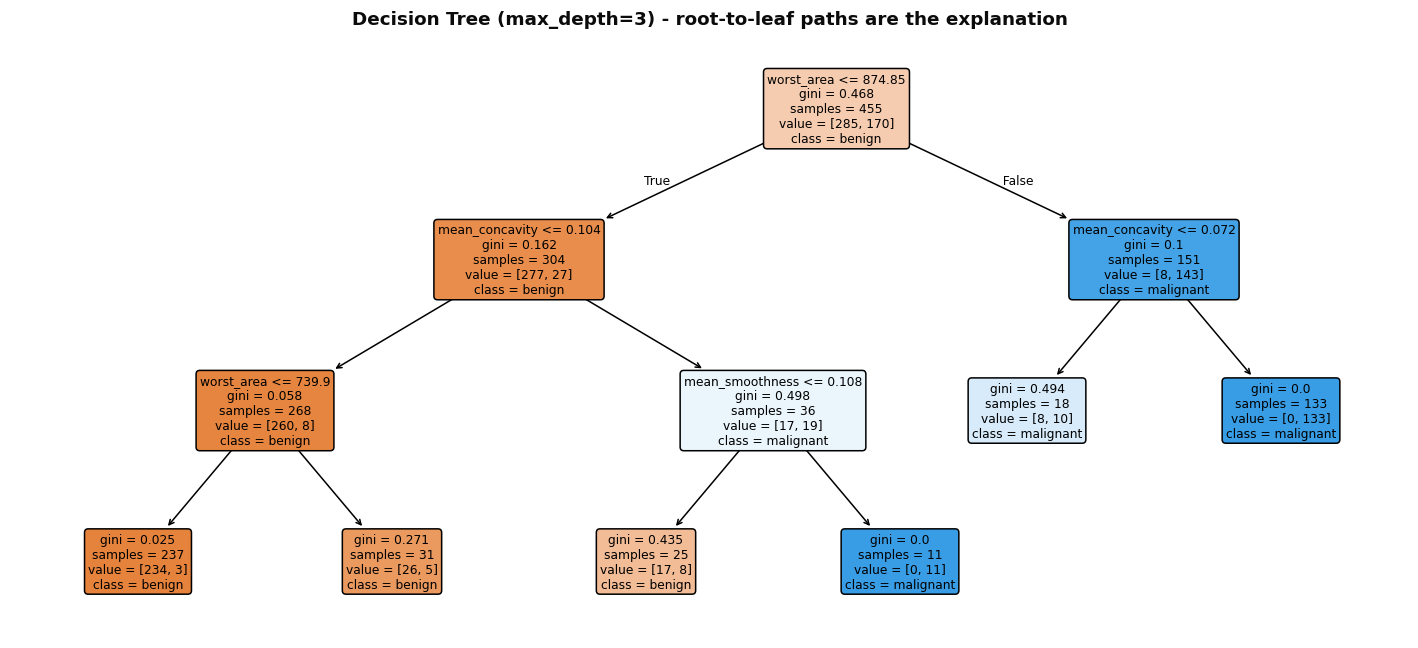

|--- worst_area <= 874.85
|   |--- mean_concavity <= 0.10
|   |   |--- worst_area <= 739.90
|   |   |   |--- class: 0
|   |   |--- worst_area >  739.90
|   |   |   |--- class: 0
|   |--- mean_concavity >  0.10
|   |   |--- mean_smoothness <= 0.11
|   |   |   |--- class: 0
|   |   |--- mean_smoothness >  0.11
|   |   |   |--- class: 1
|--- worst_area >  874.85
|   |--- mean_concavity <= 0.07
|   |   |--- class: 1
|   |--- mean_concavity >  0.07
|   |   |--- class: 1



In [4]:
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=RANDOM_STATE)
tree.fit(x_train, y_train)

pred = tree.predict(x_test)
results["Decision Tree"] = accuracy_score(y_test, pred)
print(f"Decision Tree test accuracy: {results['Decision Tree']:.3f}")
print(f"Tree depth: {tree.get_depth()}, number of leaves: {tree.get_n_leaves()}")

fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(tree, feature_names=selected_features, class_names=["benign", "malignant"],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("Decision Tree (max_depth=3) - root-to-leaf paths are the explanation")
plt.tight_layout()
plt.show()

print(export_text(tree, feature_names=selected_features))


In [5]:
# Step 11 - extract root-to-leaf paths as explicit, human-readable IF-THEN rules
def extract_rules(tree_clf, feature_names, class_names=("benign", "malignant")):
    t = tree_clf.tree_
    rules = []

    def recurse(node, conditions):
        if t.feature[node] != -2:  # internal node (-2 = leaf, sklearn's TREE_UNDEFINED)
            feat = feature_names[t.feature[node]]
            thresh = t.threshold[node]
            recurse(t.children_left[node], conditions + [f"{feat} <= {thresh:.3f}"])
            recurse(t.children_right[node], conditions + [f"{feat} > {thresh:.3f}"])
        else:
            counts = t.value[node][0]
            pred_class = class_names[int(np.argmax(counts))]
            confidence = counts.max() / counts.sum()
            rule = "IF " + " AND ".join(conditions) + f" THEN predict {pred_class}" \
                   f"  (confidence {confidence:.2f}, n={int(counts.sum())})"
            rules.append(rule)

    recurse(0, [])
    return rules


explicit_rules = extract_rules(tree, selected_features)
results["Explicit Rule List"] = results["Decision Tree"]  # same underlying model, same accuracy
print(f"Extracted {len(explicit_rules)} rules (one per leaf):\n")
for i, r in enumerate(explicit_rules, 1):
    print(f"Rule {i}: {r}")


Extracted 6 rules (one per leaf):

Rule 1: IF worst_area <= 874.850 AND mean_concavity <= 0.104 AND worst_area <= 739.900 THEN predict benign  (confidence 0.99, n=1)
Rule 2: IF worst_area <= 874.850 AND mean_concavity <= 0.104 AND worst_area > 739.900 THEN predict benign  (confidence 0.84, n=1)
Rule 3: IF worst_area <= 874.850 AND mean_concavity > 0.104 AND mean_smoothness <= 0.108 THEN predict benign  (confidence 0.68, n=1)
Rule 4: IF worst_area <= 874.850 AND mean_concavity > 0.104 AND mean_smoothness > 0.108 THEN predict malignant  (confidence 1.00, n=1)
Rule 5: IF worst_area > 874.850 AND mean_concavity <= 0.072 THEN predict malignant  (confidence 0.56, n=1)
Rule 6: IF worst_area > 874.850 AND mean_concavity > 0.072 THEN predict malignant  (confidence 1.00, n=1)


## Step 12-13: k-Nearest Neighbors (k=5)
Explains a prediction using the identities of the most similar training patients
(majority class = the prediction).

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_s, y_train)

pred = knn.predict(x_test_s)
results["k-NN (k=5)"] = accuracy_score(y_test, pred)
print(f"k-NN test accuracy: {results['k-NN (k=5)']:.3f}")

# Explain one test patient by its 5 nearest TRAINING neighbours
nn = NearestNeighbors(n_neighbors=5).fit(x_train_s)
patient_idx = x_test.index[0]
patient = x_test_s.loc[[patient_idx]]

dist, ind = nn.kneighbors(patient)
neighbour_rows = x_train.iloc[ind[0]].copy()
neighbour_rows["target"] = y_train.iloc[ind[0]].values
neighbour_rows["distance"] = dist[0].round(3)

print(f"\nTest patient #{patient_idx} - true label = "
      f"{'malignant' if y_test.loc[patient_idx] == 1 else 'benign'}, "
      f"k-NN prediction = {'malignant' if knn.predict(patient)[0] == 1 else 'benign'}\n")
print("5 nearest training patients (the explanation):")
display(neighbour_rows)

majority = neighbour_rows["target"].mean()
print(f"\n{int(neighbour_rows['target'].sum())}/5 of the nearest neighbours are malignant "
      f"-> majority vote = {'malignant' if majority > 0.5 else 'benign'}")


k-NN test accuracy: 0.956

Test patient #120 - true label = benign, k-NN prediction = benign

5 nearest training patients (the explanation):


,mean_radius,mean_texture,mean_perimeter,mean_smoothness,mean_concavity,worst_area,target,distance
401,11.93,10.91,76.14,0.08872,0.02606,589.5,0,0.434
166,10.80,9.71,68.77,0.09594,0.02531,414.0,0,0.443
158,12.06,12.74,76.84,0.09311,0.01972,532.8,0,0.541
527,12.34,12.27,78.94,0.09003,0.02958,564.9,0,0.560
313,11.54,10.72,73.73,0.08597,0.01367,467.8,0,0.609



0/5 of the nearest neighbours are malignant -> majority vote = benign


## Step 14-15: Gaussian Naive Bayes
Explains a prediction using per-feature likelihood contributions: each feature's
value is scored against a per-class Gaussian fitted on the training data.

Gaussian Naive Bayes test accuracy: 0.904

Per-class, per-feature mean (theta_):


,mean_radius,mean_texture,mean_perimeter,mean_smoothness,mean_concavity,worst_area
benign (0),12.155,18.049,78.104,0.092,0.046,561.812
malignant (1),17.537,21.713,115.873,0.103,0.161,1441.721



Per-feature log-likelihood contribution for test patient #120:


,value,log_lik(benign),log_lik(malignant),malignant - benign
mean_smoothness,0.094,2.861,2.789,-0.072
mean_concavity,0.035,2.076,0.361,-1.715
mean_radius,11.410,-1.583,-3.851,-2.268
mean_texture,10.820,-3.976,-6.276,-2.300
mean_perimeter,73.340,-3.470,-5.825,-2.355
worst_area,510.500,-6.069,-8.492,-2.423



(positive 'malignant - benign' = this feature's value pushes the prediction toward malignant)


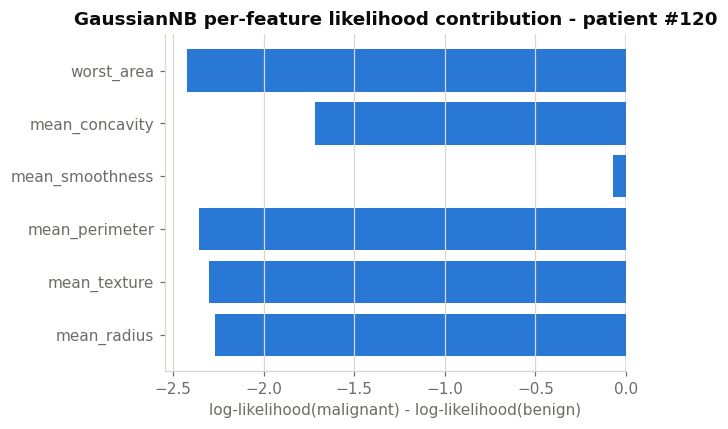

In [7]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

pred = gnb.predict(x_test)
results["Gaussian Naive Bayes"] = accuracy_score(y_test, pred)
print(f"Gaussian Naive Bayes test accuracy: {results['Gaussian Naive Bayes']:.3f}")

class_means = pd.DataFrame(gnb.theta_, index=["benign (0)", "malignant (1)"], columns=selected_features)
class_vars = pd.DataFrame(gnb.var_, index=["benign (0)", "malignant (1)"], columns=selected_features)
print("\nPer-class, per-feature mean (theta_):")
display(class_means.round(3))

# Per-feature log-likelihood contribution for the SAME test patient used above
patient_raw = x_test.loc[[patient_idx]]
log_lik_benign = norm.logpdf(patient_raw.values[0], gnb.theta_[0], np.sqrt(gnb.var_[0]))
log_lik_malignant = norm.logpdf(patient_raw.values[0], gnb.theta_[1], np.sqrt(gnb.var_[1]))

contrib = pd.DataFrame({
    "value": patient_raw.values[0],
    "log_lik(benign)": log_lik_benign,
    "log_lik(malignant)": log_lik_malignant,
    "malignant - benign": log_lik_malignant - log_lik_benign,
}, index=selected_features).round(3)
print(f"\nPer-feature log-likelihood contribution for test patient #{patient_idx}:")
display(contrib.sort_values("malignant - benign", ascending=False))
print("\n(positive 'malignant - benign' = this feature's value pushes the prediction toward malignant)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(contrib.index, contrib["malignant - benign"],
        color=[C["red"] if v > 0 else C["blue"] for v in contrib["malignant - benign"]])
ax.axvline(0, color=C["ink"], linewidth=0.8)
ax.set_title(f"GaussianNB per-feature likelihood contribution - patient #{patient_idx}")
ax.set_xlabel("log-likelihood(malignant) - log-likelihood(benign)")
ax.xaxis.grid(True)
plt.tight_layout()
plt.show()


## Step 16: Generalized Additive Model (GAM)
A separate smooth ("shape") function is learned per feature; the prediction is
the sum of the six shape functions (plus an intercept), passed through a logit
link.

GAM test accuracy: 0.974


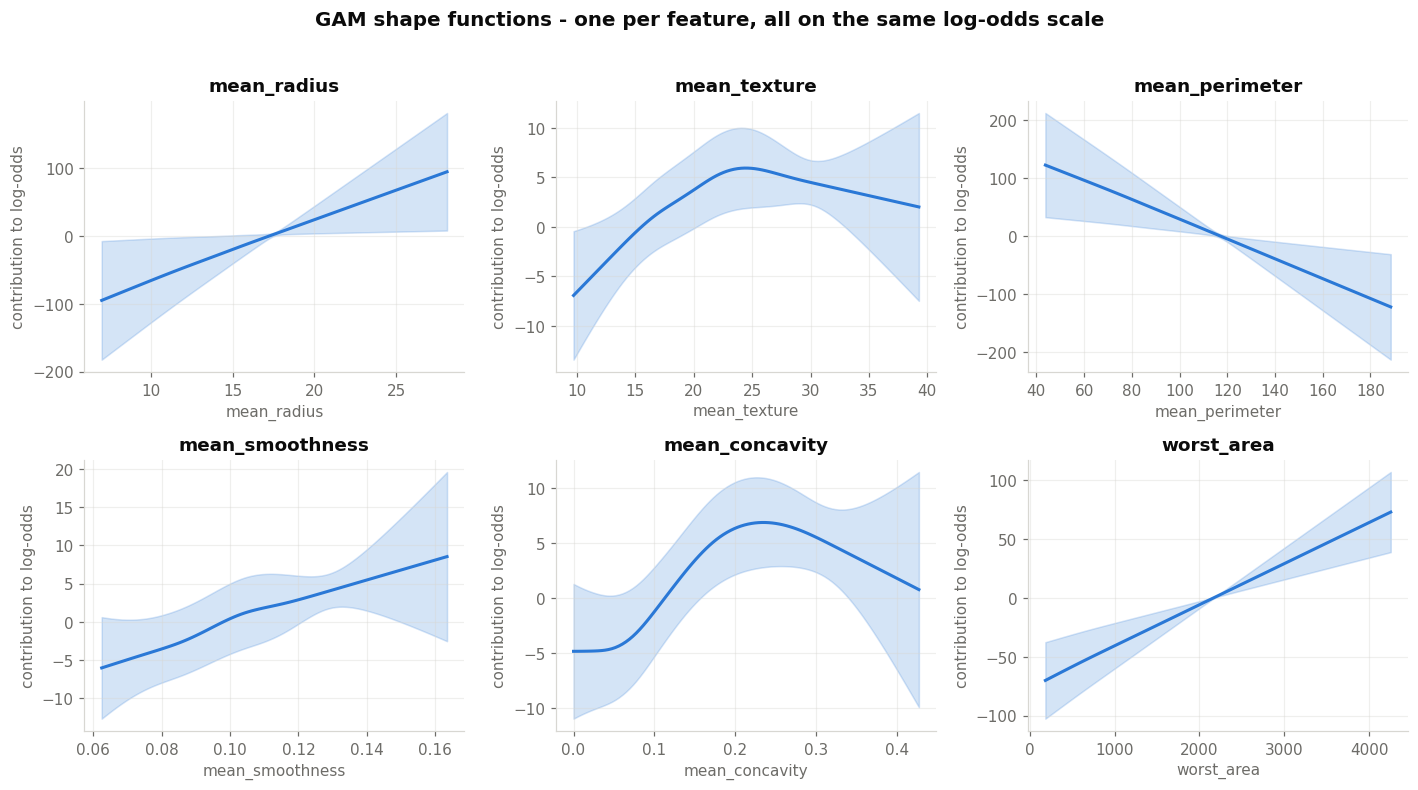

In [8]:
gam = LogisticGAM(s(0) + s(1) + s(2) + s(3) + s(4) + s(5))
gam.fit(x_train.values, y_train.values)

pred = gam.predict(x_test.values)
results["GAM"] = accuracy_score(y_test, pred)
print(f"GAM test accuracy: {results['GAM']:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for i, (ax, feat) in enumerate(zip(axes.ravel(), selected_features)):
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    ax.plot(XX[:, i], pdep, color=C["blue"], linewidth=2)
    ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], color=C["blue"], alpha=0.2)
    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("contribution to log-odds")
    ax.grid(True, alpha=0.4)

fig.suptitle("GAM shape functions - one per feature, all on the same log-odds scale", y=1.02,
             fontsize=13, fontweight="bold", color=C["ink"])
plt.tight_layout()
plt.show()


## Step 17: Evaluate all models using test accuracy

In [9]:
accuracy_table = pd.Series(results, name="test_accuracy").sort_values(ascending=False).round(4)
display(accuracy_table.to_frame())


,test_accuracy
GAM,0.9737
k-NN (k=5),0.9561
Logistic Regression,0.9298
Decision Tree,0.9211
Explicit Rule List,0.9211
Gaussian Naive Bayes,0.9035


## Step 18: Compare models - interpretability unit, units to inspect, manual simulability

- **Interpretability unit**: the single object a human reads to explain one prediction.
- **# units to inspect**: how many of those objects are needed to explain ONE prediction.
- **Manual simulability**: can a person compute the prediction by hand from the unit(s), without a computer?

In [10]:
comparison = pd.DataFrame([
    dict(model="Logistic Regression", interpretability_unit="coefficient / odds ratio",
         units_to_inspect=len(selected_features) + 1,  # 6 coefficients + intercept
         manual_simulability="Yes (exact, via sigmoid(w.x + b))"),
    dict(model="Decision Tree", interpretability_unit="decision node on the path",
         units_to_inspect=tree.get_depth(),  # depth of the path actually followed
         manual_simulability="Yes (follow the path root-to-leaf)"),
    dict(model="Explicit Rule List", interpretability_unit="IF-THEN rule",
         units_to_inspect=1,  # exactly one rule fires per prediction
         manual_simulability="Yes (most direct - a single sentence)"),
    dict(model="k-NN (k=5)", interpretability_unit="nearest training patient",
         units_to_inspect=5,
         manual_simulability="Partial (needs the whole training set + distances)"),
    dict(model="Gaussian Naive Bayes", interpretability_unit="per-feature likelihood",
         units_to_inspect=len(selected_features),  # one Gaussian evaluation per feature
         manual_simulability="Partial (Gaussian pdf per feature, tedious by hand)"),
    dict(model="GAM", interpretability_unit="shape function (curve) per feature",
         units_to_inspect=len(selected_features),
         manual_simulability="Partial (read 6 curves off a graph, then sum)"),
])
comparison["test_accuracy"] = comparison["model"].map({
    "Logistic Regression": results["Logistic Regression"],
    "Decision Tree": results["Decision Tree"],
    "Explicit Rule List": results["Explicit Rule List"],
    "k-NN (k=5)": results["k-NN (k=5)"],
    "Gaussian Naive Bayes": results["Gaussian Naive Bayes"],
    "GAM": results["GAM"],
}).round(4)
comparison = comparison[["model", "test_accuracy", "interpretability_unit", "units_to_inspect", "manual_simulability"]]
display(comparison)


,model,test_accuracy,interpretability_unit,units_to_inspect,manual_simulability
0,Logistic Regression,0.9298,coefficient / odds ratio,7,"Yes (exact, via sigmoid(w.x + b))"
1,Decision Tree,0.9211,decision node on the path,3,Yes (follow the path root-to-leaf)
2,Explicit Rule List,0.9211,IF-THEN rule,1,Yes (most direct - a single sentence)
3,k-NN (k=5),0.9561,nearest training patient,5,Partial (needs the whole training set + distan...
4,Gaussian Naive Bayes,0.9035,per-feature likelihood,6,"Partial (Gaussian pdf per feature, tedious by ..."
5,GAM,0.9737,shape function (curve) per feature,6,"Partial (read 6 curves off a graph, then sum)"


## Step 19: Plot the accuracy comparison of all models

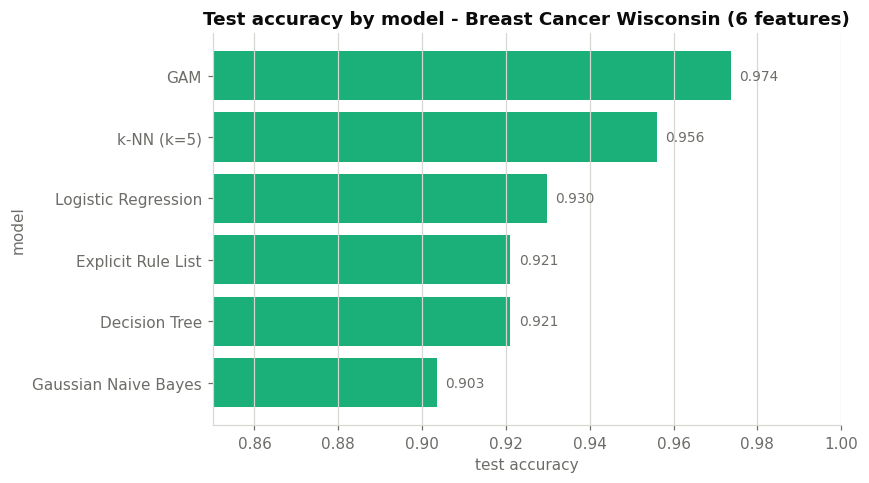

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = comparison.sort_values("test_accuracy", ascending=True)
bars = ax.barh(order["model"], order["test_accuracy"], color=C["aqua"])
ax.set_xlim(0.85, 1.0)
ax.set_title("Test accuracy by model - Breast Cancer Wisconsin (6 features)")
ax.set_xlabel("test accuracy")
ax.set_ylabel("model")
ax.xaxis.grid(True)
for bar, v in zip(bars, order["test_accuracy"]):
    ax.text(v + 0.002, bar.get_y() + bar.get_height() / 2, f"{v:.3f}", va="center", fontsize=9, color=C["muted"])
plt.tight_layout()
plt.show()


## Step 20: Accuracy-interpretability trade-off

Across all six models, test accuracy ranges narrowly (roughly 0.90-0.97), but the
work a human must do to explain any ONE prediction differs enormously:

- The **Explicit Rule List** is the cheapest to explain (exactly one short
  sentence fires per prediction) and is essentially the same accuracy as its
  parent Decision Tree, since it is a direct re-reading of the same model in
  different clothing.
- **Logistic Regression** needs six coefficients plus an intercept, but the
  computation is a single linear equation followed by a sigmoid; every
  prediction is explained by the *same* small, fixed set of numbers.
- **k-NN** and **Gaussian Naive Bayes** both explain a prediction using
  patient-specific evidence (five neighbours, or six likelihood ratios) that
  changes from patient to patient, so the "explanation" is cheap to state but
  is not a reusable global rule the way the linear/tree coefficients are.
- The **GAM** is the most accurate model here (curved rather than
  straight-line feature effects captured on the log-odds scale) but its
  explanation is a set of six graphs rather than a formula or a sentence -- a
  human reads it, rather than computes it.

There is no dominant winner: the Explicit Rule List and Decision Tree cost the
least to explain per prediction; the GAM buys the most accuracy at the price
of turning "explanation" into "read six charts." The right choice depends on
whether the audience needs a *portable rule* (rule list / tree), a *stable
global weighting* (logistic regression), *case-based evidence* (k-NN), or the
*best possible fit while remaining fully additive and visualisable* (GAM).